In [13]:
import json
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt

In [14]:
def load_data(json_file):
    try:
        with open(json_file, 'r', encoding='utf-8') as file:
            data = json.load(file)
    except UnicodeDecodeError:
        with open(json_file, 'r', encoding='latin-1') as file:
            data = json.load(file)
    
    filtered_data = [entry for entry in data if 'time' in entry and entry['time'].startswith("2024")]
    return filtered_data

In [15]:
def content_genre_analysis(data):
    import re
    from collections import Counter
    import matplotlib.pyplot as plt

    stop_words = {"the", "a", "an", "and", "or", "but", "is", "are", "was", "were", "to", "of", "in", "on", "at", "for", "with", "this", "that", "watched", "you", "your", "my", "it", "i", "we", "our", "from", "by", "as"}

    genre_keywords = {
        "Tech & Tutorials": {"tutorial", "guide", "how", "setup", "review", "unboxing", "tips", "tricks"},
        "Gaming": {"gameplay", "walkthrough", "let's", "speedrun", "challenge", "ranked", "update", "patch"},
        "Entertainment": {"trailer", "reaction", "review", "top", "explained", "ending", "scene", "movie", "series"},
        "News & Commentary": {"breaking", "news", "analysis", "update", "report", "scandal", "exposed", "leaked"},
        "Education & Science": {"explained", "why", "how", "history", "science", "myth", "facts", "experiment"},
        "Fitness & Health": {"workout", "routine", "diet", "nutrition", "fat", "muscle", "transformation", "challenge"},
        "Finance & Business": {"investing", "stocks", "money", "passive", "income", "side", "hustle", "finance", "wealth"},
        "Vlogs & Lifestyle": {"vlog", "life", "travel", "routine", "morning", "night", "update", "tour"},
        "Music": {"song", "music", "album", "track", "playlist", "lyrics", "cover", "live", "performance", "official"}
    }

    genre_count = Counter()
    
    for entry in data:
        title = entry.get('title', '').lower()
        words = set(re.findall(r'\b\w+\b', title)) - stop_words  # Extract words and remove stopwords
        for genre, keywords in genre_keywords.items():
            if words & keywords:  # Check for keyword overlap
                genre_count[genre] += 1
    
    plt.figure(figsize=(10, 5))
    plt.bar(genre_count.keys(), genre_count.values(), color='skyblue')
    plt.xlabel("Genres", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Most Frequent Genres in Watched Videos", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()
    
    return genre_count.most_common()


In [16]:
def time_spent_analysis(data):
    timestamps = [entry['time'] for entry in data]
    times = [datetime.fromisoformat(ts.replace('Z', '+00:00')) for ts in timestamps]
    
    # Filter times for 2024 only
    times = [time for time in times if time.year == 2024]
    times_by_month = Counter([time.strftime("%Y-%m") for time in times])
    
    months, counts = zip(*sorted(times_by_month.items()))
    
    plt.figure(figsize=(10, 5))
    plt.bar(months, counts, color='orange')
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Videos Watched", fontsize=12)
    plt.title("Monthly Videos Watched in 2024", fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    return times_by_month

In [17]:
def channel_popularity_analysis(data):
    channel_counts = Counter()
    for entry in data:
        subtitles = entry.get('subtitles', [])
        if subtitles:
            channel_name = subtitles[0].get('name', 'Unknown')
            channel_counts[channel_name] += 1
    
    most_popular_channels = channel_counts.most_common(10)
    if most_popular_channels:
        channels, counts = zip(*most_popular_channels)
        plt.figure(figsize=(10, 5))
        plt.bar(channels, counts, color='green')
        plt.xlabel("Channels", fontsize=12)
        plt.ylabel("Videos Watched", fontsize=12)
        plt.title("Most Popular Channels by Watch Count", fontsize=14)
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("No channel data available for analysis.")
    
    return most_popular_channels


Running Content Consumption Analysis...


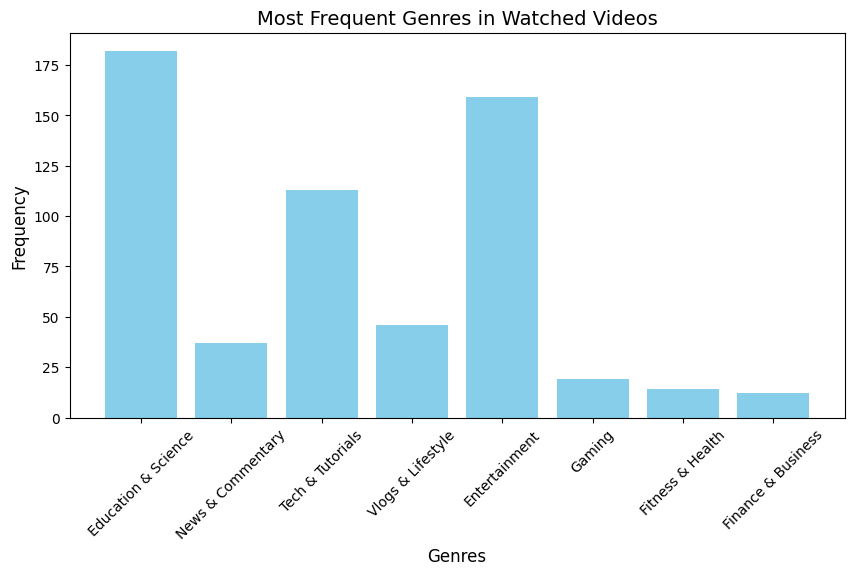

Most Common Words in Titles: [('Education & Science', 182), ('Entertainment', 159), ('Tech & Tutorials', 113), ('Vlogs & Lifestyle', 46), ('News & Commentary', 37), ('Gaming', 19), ('Fitness & Health', 14), ('Finance & Business', 12)]

Running Time Spent Analysis...


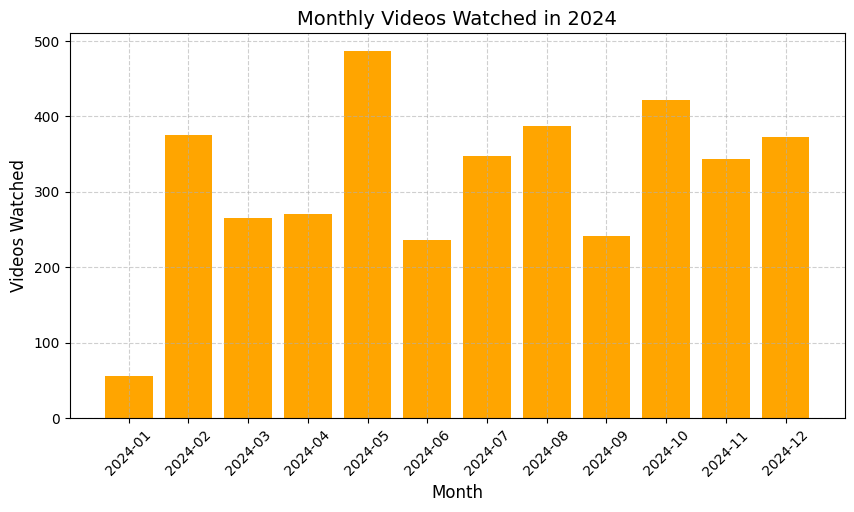

Videos Watched Per Month in 2024: Counter({'2024-05': 486, '2024-10': 422, '2024-08': 387, '2024-02': 375, '2024-12': 372, '2024-07': 348, '2024-11': 343, '2024-04': 271, '2024-03': 265, '2024-09': 241, '2024-06': 236, '2024-01': 56})

Running Channel Popularity Analysis...


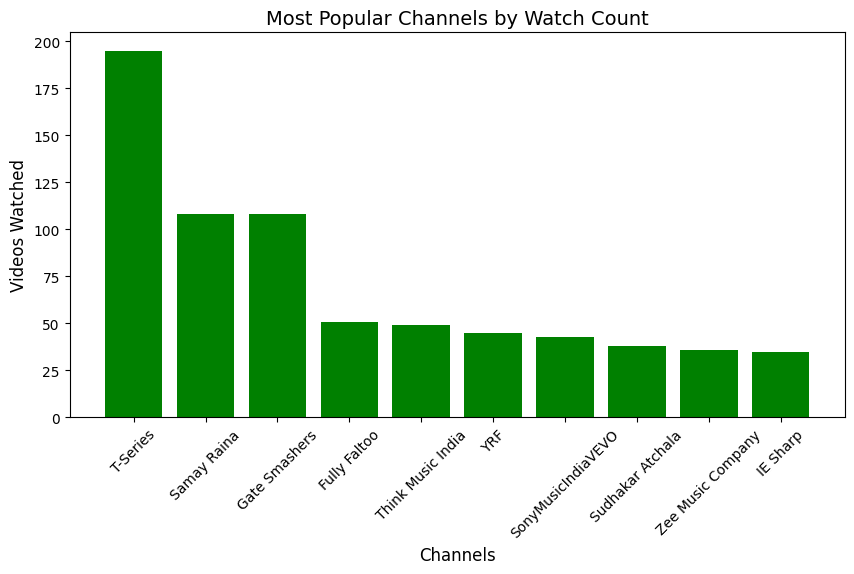

Most Popular Channels: [('T-Series', 195), ('Samay Raina', 108), ('Gate Smashers', 108), ('Fully Faltoo', 51), ('Think Music India', 49), ('YRF', 45), ('SonyMusicIndiaVEVO', 43), ('Sudhakar Atchala', 38), ('Zee Music Company', 36), ('IE Sharp', 35)]


In [18]:
if __name__ == "__main__":
    json_file = "watch-history.json" 
    data = load_data(json_file)

    print("\nRunning Content Consumption Analysis...")
    common_words = content_genre_analysis(data)
    print("Most Common Words in Titles:", common_words)

    print("\nRunning Time Spent Analysis...")
    times_by_month = time_spent_analysis(data)
    print("Videos Watched Per Month in 2024:", times_by_month)

    print("\nRunning Channel Popularity Analysis...")
    popular_channels = channel_popularity_analysis(data)
    print("Most Popular Channels:", popular_channels)